<a href="https://colab.research.google.com/github/eojin22/ESAA/blob/main/OB_0904_%EC%84%B8%EC%85%98_%EB%AA%A8%EB%8D%B8%ED%9B%88%EB%A0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___
: 수백만 개의 특성을 가진 훈련 세트에서는 **확률적 경사 하강법(SGD)** 이나 미니배치 경사 하강법을 사용할 수 있다. 훈련 세트가 메모리에 들어간다면 배치 경사 하강법도 사용할 수 있다. 반면 정규 방정식이나 SVD 기반 방법은 특성의 개수가 증가할수록 계산 복잡도가 매우 빠르게 증가하므로 사용하기 어렵다.

### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

: 에포크마다 검증 에러가 지속적으로 상승한다면 한 가지 가능성은 학습률이 너무 높아 알고리즘이 발산하는 것일 수 있다. 훈련 에러도 올라간다면 이 문제가 확실하므로, 학습률을 낮추어야 한다. 하지만 훈련 에러가 증가하지 않는다면, 모델이 훈련 세트에 과대적합 되어 있는 것이므로 훈련을 멈춰야 한다.

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

: 훈련 에러와 검증 에러가 거의 비슷하고 매우 높다면, 모델이 훈련 세트에 과소적합되었을 가능성이 높다. 즉, 높은 편향을 가진 모델이기 때문에, 규제 하이퍼파라미터  α 를 줄여야 한다.

### **4. 다음과 같이 사용해야 하는 이유는?**
___
- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
- 릿지 회귀 대신 라쏘 회귀
- 라쏘 회귀 대신 엘라스틱넷

1. 규제가 있는 모델이 일반적으로 규제가 없는 모델보다 성능이 좋기 때문이다.
2. 라쏘 회귀는  l1  페널티를 사용하여, 가중치를 완전히 0으로 만드는 경향이 있다. 이는 가장 중요한 가중치를 제외하고는 모두 0이 되는 희소한 모델을 만든다. 또한 자동으로 특성 선택의 효과를 가지므로, 일부 특성만 실제로 유용할 것 같을 때 사용하면 좋다. 확신이 없다면 릿지 회귀를 사용해야 한다.
3. 라쏘가 어떤 경우에는 불규칙하게 행동하므로, 엘라스틱넷이 라쏘보다 일반적으로 선호된다. 그러나 추가적인 하이퍼 파라미터가 생긴다. 불규칙한 행동이 없는 라쏘를 원하면 엘라스틱 넷에 l1_ratio를 1에 가깝게 설정하면 좋다.

### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



최적 검증 손실: 0.17961234456462544
훈련 정확도: 0.9666666666666667
검증 정확도: 0.9333333333333333
테스트 정확도: 0.9666666666666667


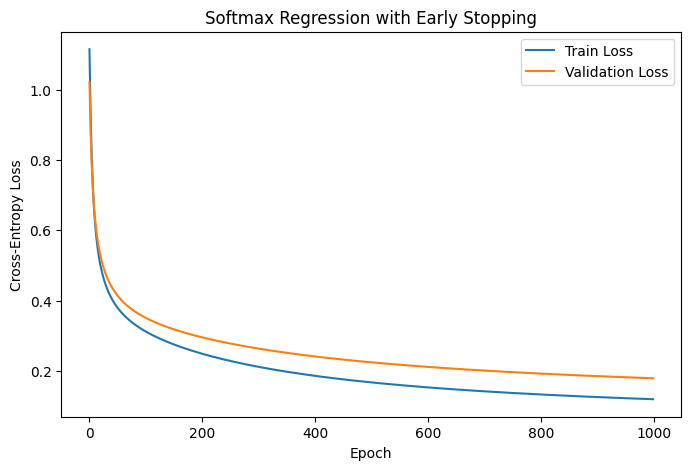

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Iris 데이터 불러오기
# 사이킷런을 사용하지 않고 UCI 저장소의 Iris 데이터를 pandas로 불러옵니다.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]

iris = pd.read_csv(url, header=None, names=columns)
iris = iris.dropna()

# 클래스 이름을 0, 1, 2로 변환
class_names = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}
iris["target"] = iris["target"].map(class_names)

X = iris.iloc[:, :4].values.astype(float)
y = iris["target"].values.astype(int)

# 2. 훈련/검증/테스트 데이터 분할
# 데이터 순서를 섞은 뒤 60%/20%/20%로 나눕니다.
np.random.seed(42)
indices = np.random.permutation(len(X))

train_size = 90
valid_size = 30

train_idx = indices[:train_size]
valid_idx = indices[train_size:train_size + valid_size]
test_idx = indices[train_size + valid_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_valid, y_valid = X[valid_idx], y[valid_idx]
X_test, y_test = X[test_idx], y[test_idx]

# 3. 표준화
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_valid = (X_valid - mean) / std
X_test = (X_test - mean) / std

# 편향항(bias)을 위한 1열 추가
X_train = np.c_[np.ones(len(X_train)), X_train]
X_valid = np.c_[np.ones(len(X_valid)), X_valid]
X_test = np.c_[np.ones(len(X_test)), X_test]

# 4. 소프트맥스 회귀에 필요한 함수
def softmax(logits):
    # 수치적으로 안정적인 계산을 위해 각 행에서 최댓값을 뺍니다.
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(y_true, probabilities):
    # y_true를 원-핫 인코딩으로 변환
    n = len(y_true)
    log_probs = np.log(probabilities[np.arange(n), y_true] + 1e-15)
    return -np.mean(log_probs)

def accuracy(y_true, probabilities):
    predictions = np.argmax(probabilities, axis=1)
    return np.mean(predictions == y_true)

# 5. 가중치 초기화
n_features = X_train.shape[1]
n_classes = 3

np.random.seed(42)
Theta = np.random.randn(n_features, n_classes) * 0.01

learning_rate = 0.1
n_epochs = 1000

# 조기 종료 설정
patience = 20
best_valid_loss = np.inf
best_theta = Theta.copy()
patience_count = 0

train_losses = []
valid_losses = []

# 6. 배치 경사 하강법 + 조기 종료
for epoch in range(n_epochs):
    # 전체 훈련 데이터를 한 번에 사용하는 배치 경사 하강법
    logits = X_train @ Theta
    probabilities = softmax(logits)

    train_loss = cross_entropy_loss(y_train, probabilities)

    # 원-핫 인코딩
    y_one_hot = np.zeros((len(y_train), n_classes))
    y_one_hot[np.arange(len(y_train)), y_train] = 1

    # 소프트맥스 회귀의 gradient
    gradients = (X_train.T @ (probabilities - y_one_hot)) / len(X_train)

    # 파라미터 업데이트
    Theta -= learning_rate * gradients

    # 검증 손실 계산
    valid_probabilities = softmax(X_valid @ Theta)
    valid_loss = cross_entropy_loss(y_valid, valid_probabilities)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # 검증 손실이 개선되면 최적 가중치 저장
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_theta = Theta.copy()
        patience_count = 0
    else:
        patience_count += 1

    # 일정 횟수 동안 개선되지 않으면 학습 중단
    if patience_count >= patience:
        print(f"조기 종료: {epoch + 1}번째 epoch")
        break

# 가장 좋은 검증 성능을 보였던 가중치 복원
Theta = best_theta

# 7. 최종 성능 평가
train_prob = softmax(X_train @ Theta)
valid_prob = softmax(X_valid @ Theta)
test_prob = softmax(X_test @ Theta)

print("최적 검증 손실:", best_valid_loss)
print("훈련 정확도:", accuracy(y_train, train_prob))
print("검증 정확도:", accuracy(y_valid, valid_prob))
print("테스트 정확도:", accuracy(y_test, test_prob))

# 8. 손실 함수 변화 확인
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Softmax Regression with Early Stopping")
plt.legend()
plt.show()
